Once all the images have been scraped, we run YOLO to detect the car in the image. We do this to reduce the noise passed down to the model further down the processing pipeline. Yolo will also help us detect shots of car details which we do not want to include in the trainingdata.

At this point I'm not sure yet if YOLO is the way to go, I'll include it anyway as it can run unattended without causing significant overhead. 

From playing around with this notebook we've established that it's difficult to minimize false negatives and false positives based on simple rules regarding the 'surface area' of an image. Yolo can help however by identifying the biggest object in the image which is likely to be the car. The generated bounding box can then be used in a further process. 

These bounding boxes generated by YOLO will help in answering the sub-question 'does it help to provide CNNs with a focus area or not?'.

This notebook was meant to play around with the abolities of YOLO, and set up some rule-based acceptance of images in the `car_detection.py` utility the actual implementation against the full dataset is done in a headless Pythonscript that could run headlessly.

In [1]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from ultralytics import YOLO
from PIL import Image 
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2  # For reading the image
##issue on UNIX systems with YOLO: https://github.com/ultralytics/yolov5/issues/1298
## There's also an issue with AMD cars ! just force it on CPU and be done with it (see plf utility)

import sys
sys.path.append('../utils')
import config_handling as conf
import car_detection as cd
import platform_dependency as plf


In [2]:
config = conf.read_config('../config/automotive.conf.ini')
yolo_path = os.path.join(config['directories']['root_dir'], config['directories']['yolo_path'])

In [3]:
#there's a bug ON Unix systems and a backported version of LZMA is required. Test the OS here: 
detected_os = plf.get_platform()
if detected_os == 'Linux':
    print('A unix system was detected, please follow these steps to patch a known UNIX bug:')
    print('https://askubuntu.com/questions/1299255/how-can-i-solve-no-module-named-lzma')

A unix system was detected, please follow these steps to patch a known UNIX bug:
https://askubuntu.com/questions/1299255/how-can-i-solve-no-module-named-lzma


In [4]:
def render_images(image_paths, title):
    """
    Render a list of images using Matplotlib.

    Parameters:
    - image_paths (list): List of file paths to the images to display.
    """
    if not image_paths:
        print("No images to display.")
        return

    # Determine the grid size for subplots (e.g., 2 columns)
    num_images = len(image_paths)
    cols = 2
    rows = (num_images + cols - 1) // cols  # Calculate rows needed
    
    # Create a figure with dynamic size
    fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
    axes = axes.flatten() if num_images > 1 else [axes]  # Handle single image case
    fig.suptitle(title)
    i = 0
    # Loop through the image paths and render each image
    for image_name,v in image_paths.items():
        is_car, image_path, box, confidence, area = v
        try:
            img = mpimg.imread(image_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(image_path), fontsize=10)
            axes[i].axis('off')  # Hide axes
            if is_car:
                x_min, y_min, x_max, y_max = box
                rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                     linewidth=2, edgecolor='red', facecolor='none')  # Use RGB color
                axes[i].add_patch(rect)
                label = f"{confidence:.2f}"
                axes[i].text(x_min, y_min, label, fontsize=12, color='white', bbox=dict(facecolor='red', alpha=0.5))
                #add the box and confidence score to the image at axes[i]
        except Exception as e:
            axes[i].text(0.5, 0.5, "Error loading image", fontsize=12, ha='center')
            axes[i].axis('off')
            print(f"Error displaying {image_path}: {e}")
        i+=1
    # Hide any unused subplot axes
    for j in range(len(image_paths), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [5]:
detected_gpu = plf.get_gpu_info()
if detected_gpu == False:
    print(f'Notebook detected {detected_os} as OS and will use CPU for tasks where it can be done')
else:
    print(f'Notebook detected {detected_os} as OS and will use the available {detected_gpu} GPU')
    if detected_gpu != 'amd': 
        print(f"{detected_gpu} GPU's were not tested - code required workarounds to get working on AMD - no guarantees given.")

Notebook detected Linux as OS and will use the available amd GPU


In [6]:
# Load the YOLO model
# yolo_path
yolomodel = YOLO(yolo_path)  # YOLOv8 nano for speed, or 'yolov8s.pt' for more accuracy
if detected_gpu == 'amd': 
    yolomodel = plf.yolo_override(yolomodel)


CPU override applied to model


In [7]:
#where are the images stored on the ssd
imdir = config['settings']['image_directory']

In [8]:
brands = os.listdir(imdir)#convenient effect of scraping and organizing by brand/model
#do some randome choices to pick a random bran, model, listing and show how YOLO handles it.
brand = random.choice(brands)
models = os.listdir(os.path.join(imdir, brand))
model = random.choice(models)
d = os.path.join(imdir, brand, model)
listing = random.choice(os.listdir(d))
listingdir = os.path.join(imdir, brand, model, listing)
print(brand, model, listing)
keep = {}
reject = {}

for root, dirs, files in os.walk(listingdir):
    for file in files:
        image_path = os.path.join(root, file)
        details = cd.is_full_car(image_path, yolomodel)
        # Check if the image shows the entire outside of a car
        if details[0]:
            keep[file] = details
        else:
            reject[file] = details

porsche Cayman d2729b50-30ed-4fa2-ae64-47461bdef73b


In [9]:
def tensor_to_coord(tensor, max): 
    v = math.ceil(tensor)

In [10]:
for k,v in keep.items():
    print(v[3])
    print(float(v[3]))
    #tensor_to_coord(v[23][0], 750)

tensor(0.8822)
0.8821872472763062
tensor(0.9516)
0.9515626430511475
tensor(0.5739)
0.5739440321922302
tensor(0.8487)
0.8487458229064941
tensor(0.5158)
0.5158435702323914
tensor(0.5511)
0.5510879755020142
tensor(0.8451)
0.8450661897659302
tensor(0.8445)
0.8445306420326233
tensor(0.6922)
0.6921753883361816


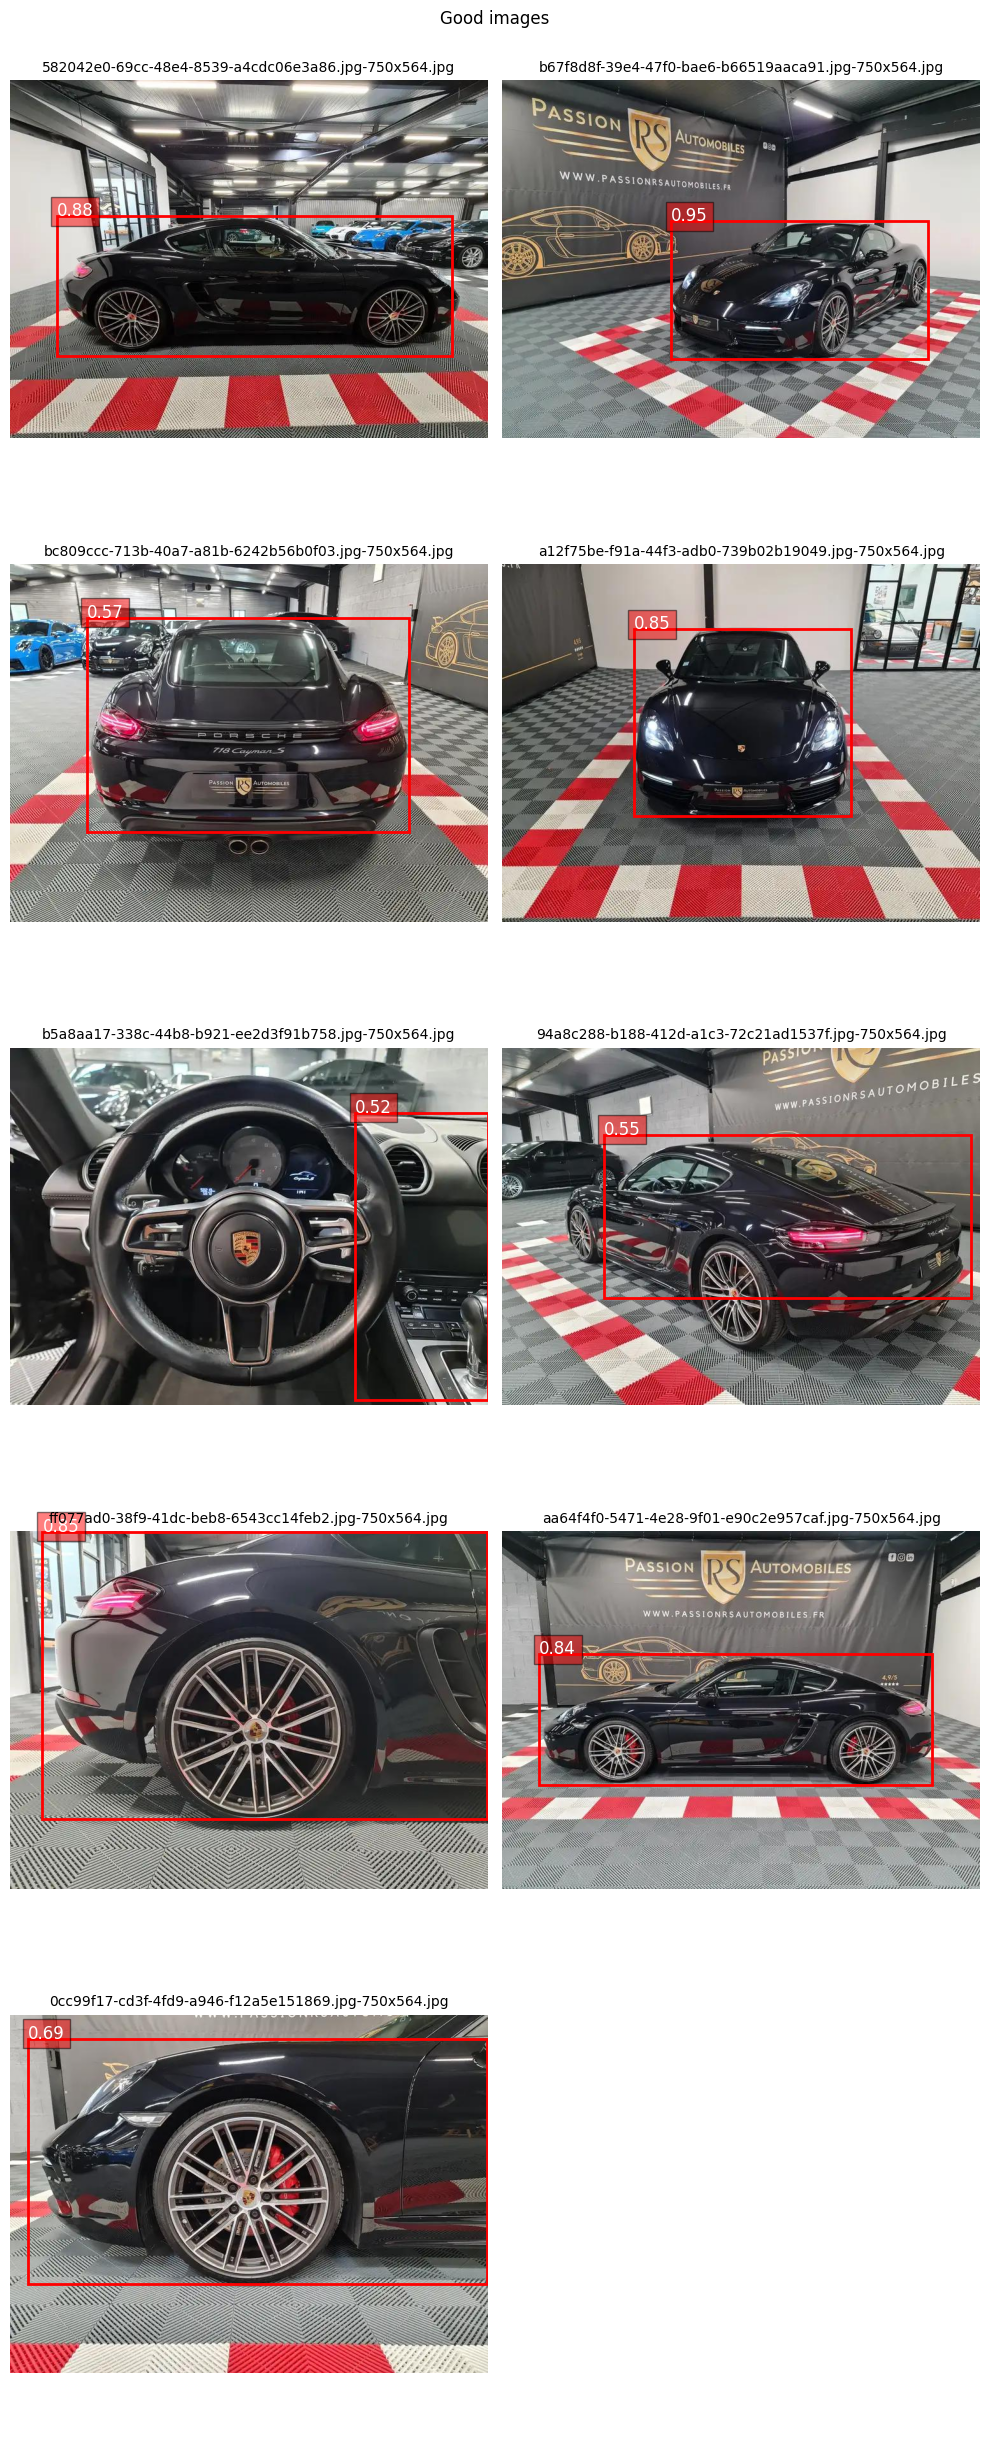

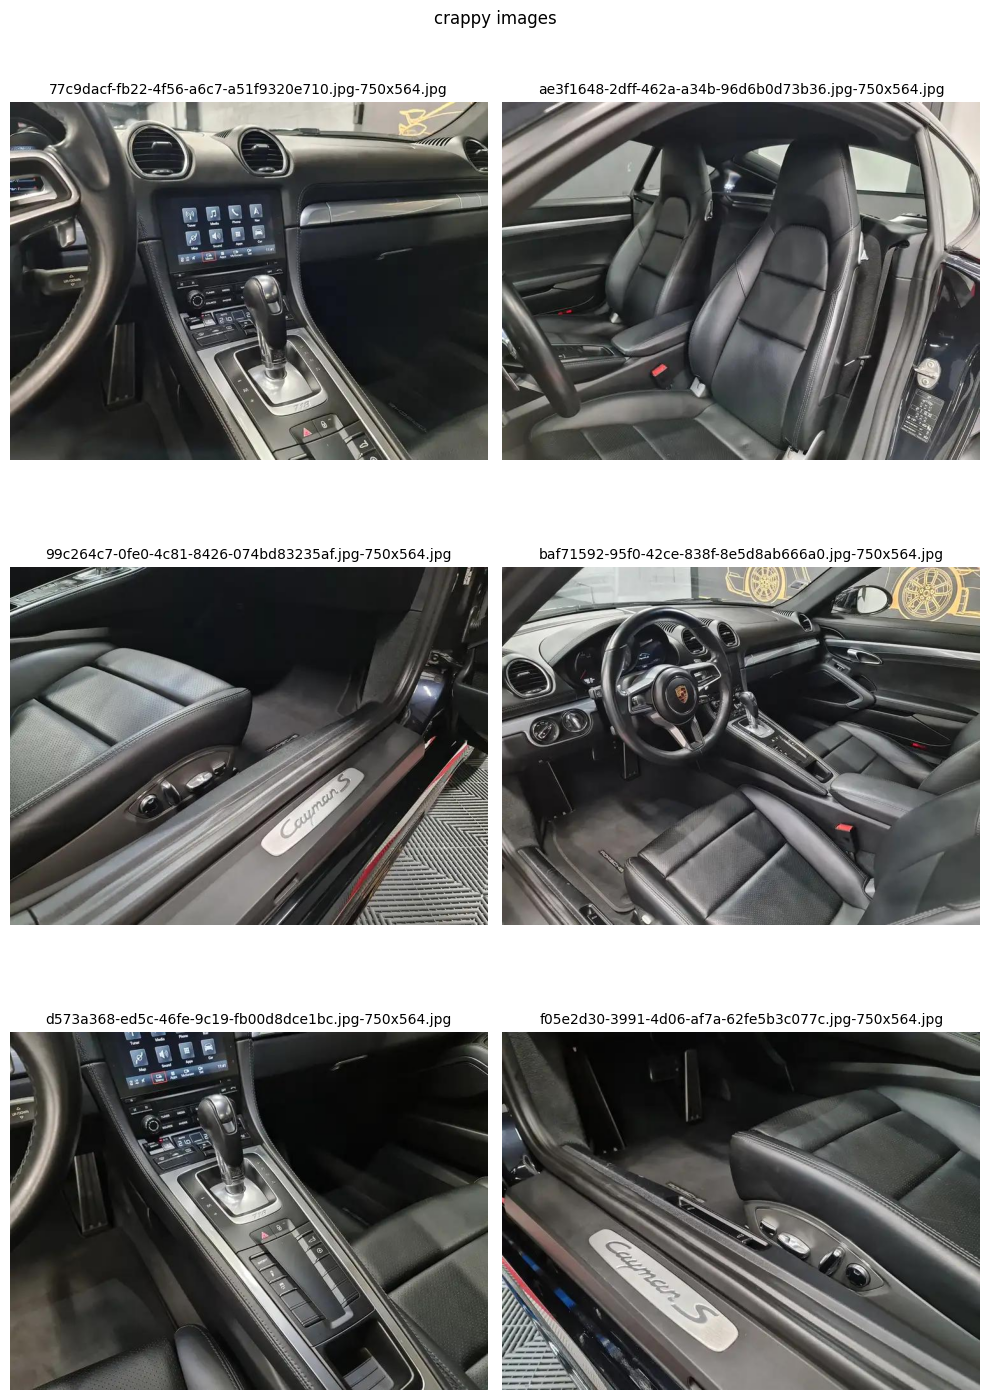

In [11]:
assert(len(keep) + len(reject) == len(files))

render_images(keep, "Good images")
render_images(reject, "crappy images")


**Conclusion**: 
Rule based approaches are not perfect to split crappy from good images. They help, but aren't perfect. With the rules applied so far we hardly get any clutter in our accepted images, so we'll stick to this and apply it on the full dataset using a headless python script. 

In [12]:

# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# import cv2  # For reading the image

# def generate_color_map(num_classes):
#     """Generate a color map for the given number of classes."""
#     colors = plt.cm.get_cmap('hsv', num_classes)
#     return [colors(i) for i in range(num_classes)]

# def visualize_detections(image_path, results):
#     # Load the image
#     image = cv2.imread(image_path)
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for matplotlib

#     # Create a figure and axis
#     fig, ax = plt.subplots(1, figsize=(12, 8))
#     ax.imshow(image)

#     # Generate a color map for the detected classes
#     num_classes = len(results[0].names)  # Assuming all results have the same class names
#     color_map = generate_color_map(num_classes)

#     # Iterate through the detection results
#     for result in results:
#         for box, cls_id, score in zip(result.boxes.xyxy, result.boxes.cls, result.boxes.conf):
#             print(box)
#             # Extract box coordinates
#             x_min, y_min, x_max, y_max = box
#             class_name = result.names[int(cls_id)]  # Get class name
#             confidence = score  # Confidence score

#             # Choose a color for the class
#             color = color_map[int(cls_id)]

#             # Create a rectangle patch
#             rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
#                                      linewidth=2, edgecolor=color[:3], facecolor='none')  # Use RGB color
#             ax.add_patch(rect)

#             # Prepare the label with class name and confidence
#             label = f"{class_name}: {confidence:.2f}"
#             ax.text(x_min, y_min, label, fontsize=12, color='white', bbox=dict(facecolor=color[:3], alpha=0.5))

#     # Show the image with detections
#     plt.axis('off')  # Hide the axis
#     plt.show()

